 # Whose City Is It?
 Comparing Airbnb commercial vs casual hosts in NYC and Dallas.
 NYC enforced Local Law 18 (Sept 2023) and listings cratered; Dallas passed a similar
 ban but it got stuck in court, so STRs are still everywhere. Wanted to see what that actually looks like in the data.

 Data: Inside Airbnb (detailed listings.csv.gz per city) -> ./data/
 By: Lekha Londhe

In [ ]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)

cities = {
    "NYC": "data/nyc_listings.csv.gz",
    "Dallas": "data/dallas_listings.csv.gz",
}

In [ ]:
# load both cities, tag each, stack them
parts = []
for name, path in cities.items():
    d = pd.read_csv(path, low_memory=False)
    d["city"] = name
    parts.append(d)
    print(f"{name}: {len(d):,} rows, {d.shape[1]} cols")

raw = pd.concat(parts, ignore_index=True)
print("combined:", raw.shape)

NYC: 35,036 rows, 91 cols
Dallas: 5,773 rows, 86 cols
combined: (40809, 91)
combined: (40809, 91)


 ## Cleaning
 the usual inside airbnb mess: price is a string, rates have % signs, dates are text.

In [ ]:
df = raw.copy()

# striping prices in dollars down to a number
df["price"] = (
    df["price"].astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .replace({"nan": np.nan, "": np.nan})
    .astype(float)
)

# "95%" -> 0.95
for c in ["host_response_rate", "host_acceptance_rate"]:
    if c in df:
        df[c] = df[c].astype(str).str.replace("%", "").replace(
            {"nan": np.nan, "": np.nan}).astype(float) / 100

for c in ["last_review", "host_since", "first_review"]:
    if c in df:
        df[c] = pd.to_datetime(df[c], errors="coerce")

# nyc and dallas name this column slightly differently
nb = "neighbourhood_cleansed" if "neighbourhood_cleansed" in df else "neighbourhood"
df["neighbourhood"] = df[nb].astype(str).str.strip()

# no reviews basically = never booked, keep that as a flag
df["ever_reviewed"] = df["number_of_reviews"].fillna(0) > 0

# flag weird prices instead of dropping them (a LOT are missing in recent snapshots)
df["bad_price"] = df["price"].isna() | (df["price"] <= 0) | (df["price"] > 5000)
print("flagged bad/missing prices:", int(df["bad_price"].sum()))

# kill duplicate listing ids, keep the latest
df = df.sort_values("last_review").drop_duplicates("id", keep="last")
print("after cleaning:", df.shape)

flagged bad/missing prices: 20142
after cleaning: (40809, 93)


 ## Commercial vs casual
 the rule: entire home + available most of the year + host runs more than one place.
 thats the profile of an operator, not someone renting their spare room.

In [ ]:
# how many entire-home listings does each host run
col = "calculated_host_listings_count_entire_homes"
if col in df:
    df["host_homes"] = df[col]
else:
    df["host_homes"] = (
        df[df.room_type == "Entire home/apt"].groupby("host_id")["id"].transform("count")
    ).reindex(df.index).fillna(0)

hostcol = "calculated_host_listings_count" if "calculated_host_listings_count" in df else "host_listings_count"


def label(row, days=180):
    entire = row.room_type == "Entire home/apt"
    full = row.get("availability_365", 0) >= days
    multi = row.host_homes > 1 or row.get(hostcol, 1) > 1
    if entire and full and multi:
        return "Commercial"
    if entire and full:
        return "Likely full-time"
    return "Casual"


df["host_type"] = df.apply(label, axis=1)
print(df.groupby("city")["host_type"].value_counts(normalize=True).round(3))

city    host_type       
Dallas  Commercial          0.446
        Casual              0.375
        Likely full-time    0.179
NYC     Casual              0.747
        Commercial          0.169
        Likely full-time    0.085
Name: proportion, dtype: float64


In [ ]:
# does the gap survive if I move the availability cutoff around? (it does)
for days in [90, 180, 240]:
    s = df.assign(x=df.apply(lambda r: label(r, days), axis=1).eq("Commercial")).groupby("city")["x"].mean()
    print(f"avail>={days}:", dict(s.round(3)))

avail>=90: {'Dallas': np.float64(0.506), 'NYC': np.float64(0.2)}
avail>=180: {'Dallas': np.float64(0.446), 'NYC': np.float64(0.169)}
avail>=240: {'Dallas': np.float64(0.405), 'NYC': np.float64(0.143)}


 ## What it looks like

host_type  Casual  Commercial  Likely full-time
city                                           
Dallas      0.375       0.446             0.179
NYC         0.747       0.169             0.085


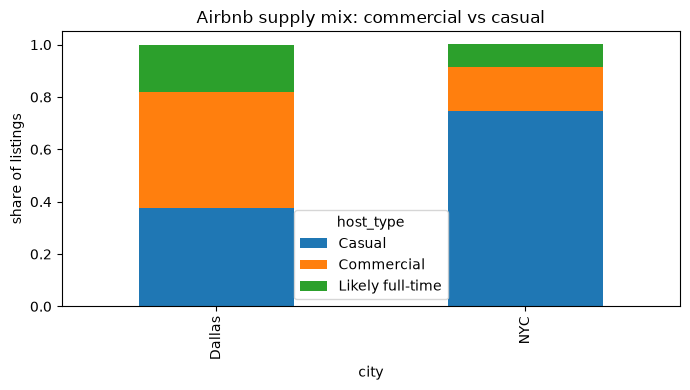

In [ ]:
# supply mix per city
mix = df.groupby(["city", "host_type"]).size().unstack(fill_value=0)
mix = mix.div(mix.sum(axis=1), axis=0).round(3)
print(mix)

mix.plot(kind="bar", stacked=True, figsize=(7, 4))
plt.title("Airbnb supply mix: commercial vs casual")
plt.ylabel("share of listings")
plt.tight_layout()
plt.savefig("supply_mix.png", dpi=150)

In [ ]:
# are a few mega-hosts driving this? (turns out, not really)
for name, g in df.groupby("city"):
    top = g.host_id.value_counts().head(10).sum()
    print(f"{name}: top-10 hosts = {top/len(g):.1%} of listings")

Dallas: top-10 hosts = 10.3% of listings
NYC: top-10 hosts = 8.9% of listings


In [ ]:
# which neighborhoods have the most commercial pressure
comm = df[df.host_type == "Commercial"]
pressure = comm.groupby(["city", "neighbourhood"]).size().rename("commercial").reset_index()
pressure = pressure.merge(
    df.groupby(["city", "neighbourhood"]).size().rename("total").reset_index(),
    on=["city", "neighbourhood"],
)
pressure["share"] = (pressure.commercial / pressure.total).round(3)

for name in cities:
    print(f"\n{name} -- top neighborhoods by commercial listings")
    print(pressure[pressure.city == name].sort_values("commercial", ascending=False).head(10).to_string(index=False))


NYC -- top neighborhoods by commercial listings
city      neighbourhood  commercial  total  share
 NYC            Midtown         635   2037  0.312
 NYC    Upper East Side         610   1355  0.450
 NYC     Hell's Kitchen         560   1508  0.371
 NYC    Upper West Side         363   1450  0.250
 NYC            Chelsea         237    831  0.285
 NYC        Murray Hill         215    473  0.455
 NYC Bedford-Stuyvesant         209   2408  0.087
 NYC Financial District         208    638  0.326
 NYC             Harlem         205   1637  0.125
 NYC           Kips Bay         162    387  0.419

Dallas -- top neighborhoods by commercial listings
  city neighbourhood  commercial  total  share
Dallas    District 2        1030   1832  0.562
Dallas   District 14         562   1164  0.483
Dallas    District 1         272    601  0.453
Dallas    District 6         140    375  0.373
Dallas   District 13         116    258  0.450
Dallas   District 11          98    301  0.326
Dallas   District 12

 ## Map
 choropleth of commercial share per neighborhood. need the neighbourhoods.geojson
 for each city from inside airbnb, saved as data/<city>_neighbourhoods.geojson.

In [ ]:
import folium

# share is noisy when a neighborhood barely has any listings (3 of 5 = 60% means nothing).
# only color neighborhoods with a real sample so the map shows actual concentration.
MIN_LISTINGS = 50
mappable = pressure[pressure.total >= MIN_LISTINGS].copy()
print(f"keeping {len(mappable)} of {len(pressure)} neighborhoods (>= {MIN_LISTINGS} listings)")
 
geojson = {
    "NYC": ("data/nyc_neighbourhoods.geojson", [40.71, -73.99]),
    "Dallas": ("data/dallas_neighbourhoods.geojson", [32.78, -96.80]),
}
 
 
def city_map(name):
    path, center = geojson[name]
    gj = json.load(open(path))
    d = mappable[mappable.city == name]
    m = folium.Map(location=center, zoom_start=11, tiles="cartodbpositron")
    folium.Choropleth(
        geo_data=gj,
        data=d,
        columns=["neighbourhood", "share"],
        key_on="feature.properties.neighbourhood",
        fill_color="OrRd",
        fill_opacity=0.75,
        line_opacity=0.3,
        nan_fill_color="whitesmoke",  # gray = too few listings to judge
        nan_fill_opacity=0.4,
        legend_name=f"commercial share of listings (neighborhoods w/ 50+ listings) — {name}",
    ).add_to(m)
    m.save(f"map_{name.lower()}.html")
    return m


city_map("NYC")

keeping 105 of 189 neighborhoods (>= 50 listings)


In [ ]:
city_map("Dallas")

## %% [markdown]
# ## Takeaway
#
# Enforcement changes who Airbnb is for. In NYC, where Local Law 18 is enforced,
# commercial operators are just 17% of listings and casual hosts are 75%. In Dallas,
# where a similar ban was blocked in court, commercial listings are 45%, about 2.6x
# NYC's share, and the gap holds across every availability threshold I tested. It isn't a
# few mega-hosts (top-10 hosts are ~9-10% of listings in both cities) but a broad
# commercial category, concentrated in the Manhattan core and Dallas's District 2 (56% of
# its listings). The catch: NYC's ban cut listings ~92% but rents still didn't fall, so
# the fix is targeted regulation of the commercial profile plus more housing supply, not a
# ban alone.

 ## Takeaway

 Enforcement changes who Airbnb is for. In NYC, where Local Law 18 is enforced,
 commercial operators are just 17% of listings and casual hosts are 75%. In Dallas,
 where a similar ban was blocked in court, commercial listings are 45%, about 2.6x
 NYC's share, and the gap holds across every availability threshold I tested. It isn't a
 few mega-hosts (top-10 hosts are ~9-10% of listings in both cities) but a broad
 commercial category, concentrated in the Manhattan core and Dallas's District 2 (56% of
 its listings). The catch: NYC's ban cut listings ~92% but rents still didn't fall, so
 the fix is targeted regulation of the commercial profile plus more housing supply, not a
 ban alone.